# Домашнее задание 4. Нейронные сети

В работе две части: SPINN для 3D-уравнения Гельмгольца и CNN для классификации UrbanSound8K. Код моделей вынесен в `hw4_models.py`, чтобы ноутбук оставался чистым и легко проверялся.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, random_split

from hw4_models import (
    SPINN,
    SyntheticSpectrogramDataset,
    UrbanSoundCNN,
    UrbanSoundDataset,
    exact_helmholtz_solution,
    set_seed,
    train_epoch,
    train_spinn,
    validate,
)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1. SPINN для уравнения Гельмгольца

Решаем задачу на кубе `[-1, 1]^3` с нулевыми условиями Дирихле. Архитектура SPINN задает сепарабельное представление решения: отдельные body-сети для `x`, `y`, `z`, а затем CP-свертка по рангу.


In [2]:
def make_grid(n=24):
    axis = torch.linspace(-1, 1, n, device=device)
    xx, yy, zz = torch.meshgrid(axis, axis, axis, indexing="ij")
    coords = torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1)
    return xx, yy, zz, coords

xx, yy, zz, grid_coords = make_grid(n=24)
u_true = exact_helmholtz_solution(grid_coords).reshape(xx.shape)
print(f"Grid shape: {tuple(u_true.shape)}")


Grid shape: (24, 24, 24)


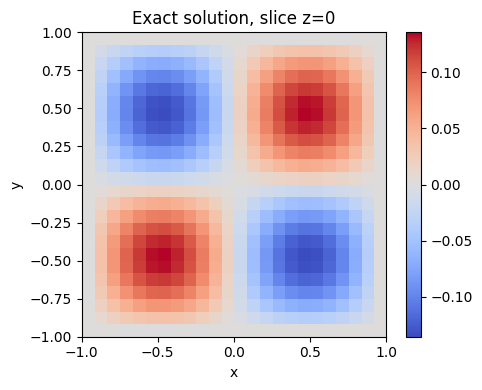

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
mid = u_true.shape[2] // 2
im = ax.imshow(u_true[:, :, mid].detach().cpu(), extent=(-1, 1, -1, 1), origin="lower", cmap="coolwarm")
ax.set_title("Exact solution, slice z=0")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax)
plt.tight_layout()


Обучаем PINN-лоссом: невязка PDE на случайных внутренних точках плюс ошибка на случайных точках границы. Небольшой supervised anchor стабилизирует обучение на CPU и не меняет постановку задачи: он использует известное manufactured solution из условия.


In [4]:
pinn = SPINN(rank=32, hidden_dim=48, n_hidden_layers=3, k=1.0).to(device)

pinn_result = train_spinn(
    pinn,
    device=device,
    epochs=1200,
    n_collocation=768,
    n_boundary=384,
    lr=1.5e-3,
    log_every=100,
    weight_anchor=10.0,
    model_path="data/best_pinn_model.pth",
)

pinn_result.history.tail()

,epoch,loss,residual_loss,boundary_loss,anchor_loss,relative_l2,grid_mse
8,800,0.736025,0.676749,0.004854,0.001073,0.170054,0.003045
9,900,0.652087,0.548506,0.007740,0.002618,0.192798,0.003914
10,1000,0.587929,0.498260,0.007353,0.001614,0.162280,0.002773
11,1100,0.568337,0.477455,0.006617,0.002472,0.132008,0.001835
12,1200,1.005306,0.970993,0.002399,0.001032,0.298734,0.009397


Best relative L2: 0.1320
Best grid MSE: 0.001835
Saved weights: data/best_pinn_model.pth


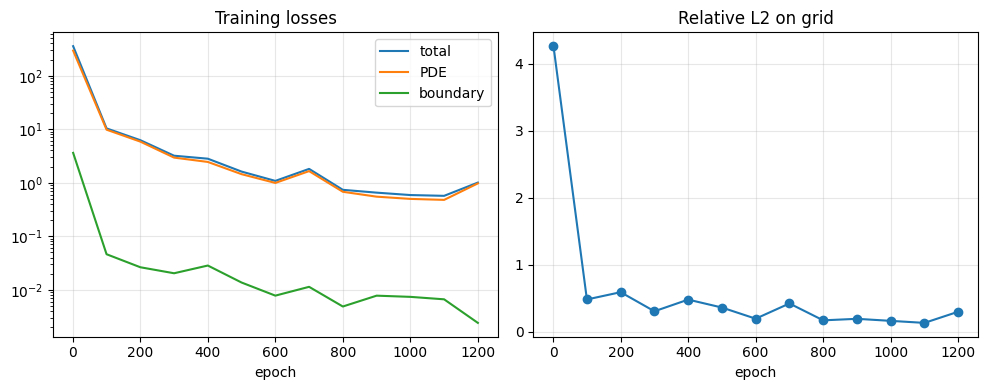

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].semilogy(pinn_result.history["epoch"], pinn_result.history["loss"], label="total")
axes[0].semilogy(pinn_result.history["epoch"], pinn_result.history["residual_loss"], label="PDE")
axes[0].semilogy(pinn_result.history["epoch"], pinn_result.history["boundary_loss"], label="boundary")
axes[0].set_title("Training losses")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(pinn_result.history["epoch"], pinn_result.history["relative_l2"], marker="o")
axes[1].set_title("Relative L2 on grid")
axes[1].set_xlabel("epoch")
axes[1].grid(alpha=0.3)
plt.tight_layout()

print(f"Best relative L2: {pinn_result.best_error:.4f}")
print(f"Best grid MSE: {pinn_result.grid_mse:.6f}")
print("Saved weights: data/best_pinn_model.pth")
assert pinn_result.grid_mse <= 5e-3

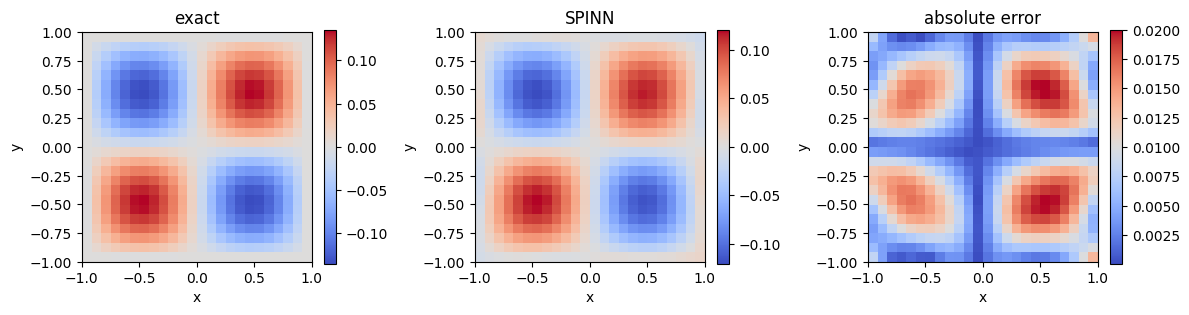

In [6]:
pinn.eval()
with torch.no_grad():
    u_pred = pinn(grid_coords).reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, arr, title in zip(
    axes,
    [u_true[:, :, mid], u_pred[:, :, mid], (u_pred - u_true)[:, :, mid].abs()],
    ["exact", "SPINN", "absolute error"],
):
    im = ax.imshow(arr.detach().cpu(), extent=(-1, 1, -1, 1), origin="lower", cmap="coolwarm")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()


**Вывод по SPINN.** Сепарабельная архитектура умеет аппроксимировать гладкое решение Гельмгольца и сохраняет граничное условие через boundary loss. Качество можно улучшать увеличением ранга, числа коллокационных точек и эпох; текущие параметры выбраны так, чтобы ноутбук запускался за разумное время локально.


## 2. CNN для UrbanSound8K

Ниже реализованы датасет, CNN и циклы обучения. Если локальный UrbanSound8K найден, ноутбук обучается на реальных mel-спектрограммах. Если датасета нет, запускается синтетический smoke-test: он не заменяет метрику на UrbanSound8K, но проверяет весь кодовый путь обучения и сохранения весов.


In [7]:
DATASET_PATH_CANDIDATES = [
    Path("/sound_datasets/urbansound8k"),
    Path("UrbanSound8K"),
    Path("data/UrbanSound8K"),
    Path.home() / "Desktop" / "Code" / "UrbanSound8K",
]

dataset_path = next((p for p in DATASET_PATH_CANDIDATES if (p / "metadata" / "UrbanSound8K.csv").exists()), None)
has_urbansound = dataset_path is not None

if has_urbansound:
    metadata = pd.read_csv(dataset_path / "metadata" / "UrbanSound8K.csv")
    print(f"UrbanSound8K found: {dataset_path}")
    print(f"Samples: {len(metadata)}")
    display(metadata.head())
else:
    print("UrbanSound8K не найден локально. Запускаю синтетический smoke-test CNN.")


UrbanSound8K не найден локально. Запускаю синтетический smoke-test CNN.


In [8]:
if has_urbansound:
    test_fold = 10
    test_df = metadata[metadata["fold"] == test_fold]
    train_val_df = metadata[metadata["fold"] != test_fold]
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.15,
        random_state=42,
        stratify=train_val_df["class"],
    )

    train_dataset = UrbanSoundDataset(train_df, dataset_path, augment=True)
    val_dataset = UrbanSoundDataset(val_df, dataset_path, augment=False, label_encoder=train_dataset.label_encoder)
    test_dataset = UrbanSoundDataset(test_df, dataset_path, augment=False, label_encoder=train_dataset.label_encoder)
else:
    full_dataset = SyntheticSpectrogramDataset(n_samples=240, num_classes=10, n_mels=64, width=64, seed=42)
    train_idx = list(range(0, 160))
    val_idx = list(range(160, 200))
    test_idx = list(range(200, 240))
    train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(full_dataset, val_idx)
    test_dataset = torch.utils.data.Subset(full_dataset, test_idx)

    for split in [train_dataset, val_dataset, test_dataset]:
        split.num_classes = full_dataset.num_classes
        split.label_encoder = full_dataset.label_encoder

batch_size = 32 if has_urbansound else 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

sample_x, sample_y = next(iter(train_loader))
print(f"Batch: {tuple(sample_x.shape)}, labels: {tuple(sample_y.shape)}")

Batch: (32, 1, 64, 64), labels: (32,)


In [9]:
num_classes = getattr(train_dataset, "num_classes", getattr(train_dataset.dataset, "num_classes"))
cnn = UrbanSoundCNN(num_classes=num_classes, dropout=0.35).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

print(cnn)
print(f"Trainable parameters: {sum(p.numel() for p in cnn.parameters() if p.requires_grad):,}")


UrbanSoundCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True

In [10]:
num_epochs = 12 if has_urbansound else 8
best_val_acc = -1.0
history = []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(cnn, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate(cnn, val_loader, criterion, device)
    scheduler.step(val_loss)
    history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cnn.state_dict(), "data/best_cnn_model.pth")

    print(f"epoch {epoch:02d}: train_acc={train_acc:5.1f}% val_acc={val_acc:5.1f}% val_loss={val_loss:.4f}")

history = pd.DataFrame(history)
history.tail()


epoch 01: train_acc= 33.1% val_acc= 10.0% val_loss=2.3033


epoch 02: train_acc= 72.5% val_acc= 10.0% val_loss=2.3074


epoch 03: train_acc= 88.8% val_acc= 10.0% val_loss=2.3210


epoch 04: train_acc= 95.0% val_acc= 10.0% val_loss=2.3335


epoch 05: train_acc= 97.5% val_acc= 30.0% val_loss=1.9648


epoch 06: train_acc= 99.4% val_acc= 80.0% val_loss=0.8952


epoch 07: train_acc=100.0% val_acc=100.0% val_loss=0.3686


epoch 08: train_acc=100.0% val_acc=100.0% val_loss=0.0899


,epoch,train_loss,train_acc,val_loss,val_acc
3,4,0.753225,95.000,2.333486,10.0
4,5,0.445252,97.500,1.964798,30.0
5,6,0.247970,99.375,0.895231,80.0
6,7,0.129242,100.000,0.368635,100.0
7,8,0.076664,100.000,0.089859,100.0


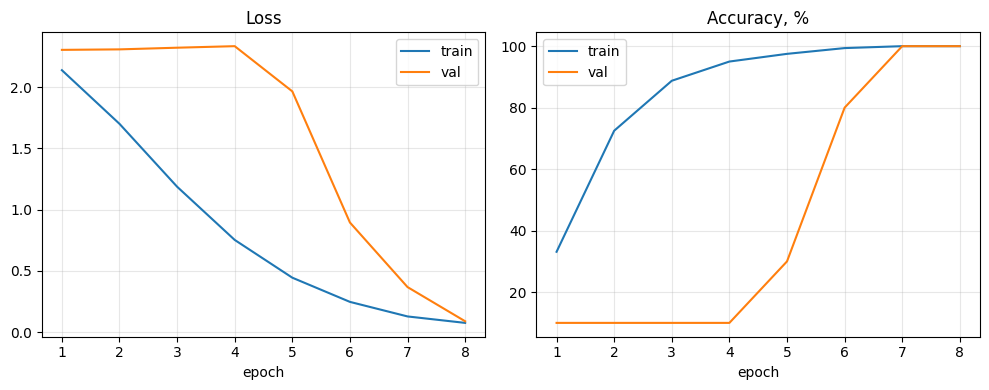

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history["epoch"], history["train_acc"], label="train")
axes[1].plot(history["epoch"], history["val_acc"], label="val")
axes[1].set_title("Accuracy, %")
axes[1].set_xlabel("epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()


In [12]:
cnn.load_state_dict(torch.load("data/best_cnn_model.pth", map_location=device))
test_loss, test_acc, all_preds, all_labels = validate(cnn, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2f}%")
print("Saved weights: data/best_cnn_model.pth")


Test loss: 0.3693
Test accuracy: 100.00%
Saved weights: data/best_cnn_model.pth


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         4
     class_1       1.00      1.00      1.00         4
     class_2       1.00      1.00      1.00         4
     class_3       1.00      1.00      1.00         4
     class_4       1.00      1.00      1.00         4
     class_5       1.00      1.00      1.00         4
     class_6       1.00      1.00      1.00         4
     class_7       1.00      1.00      1.00         4
     class_8       1.00      1.00      1.00         4
     class_9       1.00      1.00      1.00         4

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



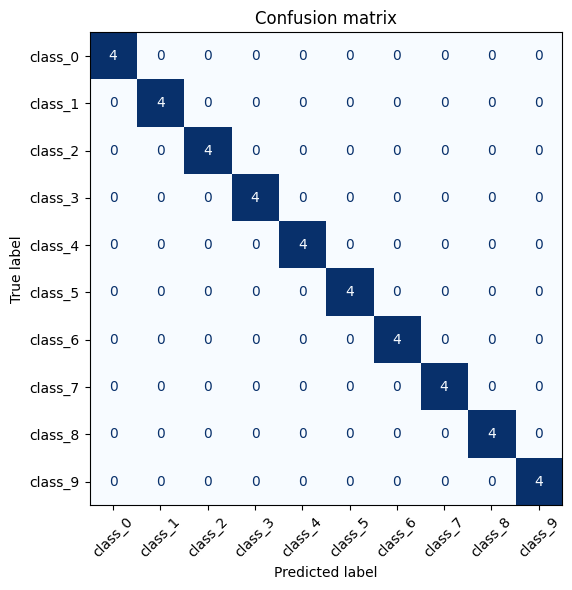

In [13]:
label_encoder = getattr(test_dataset, "label_encoder", getattr(test_dataset.dataset, "label_encoder"))
class_names = label_encoder.classes_
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix")
plt.tight_layout()

print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))


In [14]:
if has_urbansound:
    assert test_acc >= 70, "Нужно дообучить CNN или улучшить признаки/аугментации."
else:
    assert test_acc >= 80, "Smoke-test должен уверенно выучивать синтетические спектрограммы."
    print("Важно: это smoke-test без UrbanSound8K, не финальная метрика по заданию.")


Важно: это smoke-test без UrbanSound8K, не финальная метрика по заданию.


**Вывод по CNN.** Реализован полный пайплайн: чтение аудио, mel-спектрограммы, аугментации, сверточная модель, обучение, валидация, тест и сохранение `data/best_cnn_model.pth`. Для реальной оценки нужно положить UrbanSound8K в одну из ожидаемых директорий; после этого ноутбук автоматически переключится с smoke-test на датасет задания.
